In [6]:
%load_ext autoreload
%autoreload 2

import os
import sys
from os.path import join as pjoin
from pathlib import Path

os.environ['USE_PYGEOS'] = '0'

# Get project root
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent

print(f"Project root: {project_root}")

# Add PROJECT ROOT to sys.path
sys.path.insert(0, str(project_root))

from scripts.data_loading import load_stack
from scripts.features import prepare_data
import scripts.model as model
# from scripts.model import train_gmm, train_kmeans, train_model, predict_kmeans, save_labels_timeseries, print_cluster_distribution
from scripts.data_loading import compute_bands_all
import scripts.visualization as visualization
import scripts.cache as cache
import scripts.config as config

import matplotlib.pyplot as plt
import rioxarray
import numpy as np
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: c:\Users\phili\OneDrive\Desktop\Data Science\ADS\Spatial Statistics and Machine Learning\coral-reefs


In [7]:
# ================== Preprocessing ==================
bands_all = cache.cache_bands(
    "bands_all",
    compute_fn=lambda: compute_bands_all(),
    force_recompute=config.FORCE_BANDS
)

[EXISTS] Loading cached bands bands_all from interim/


 - Loading bands: 100%|██████████| 11/11 [01:29<00:00,  8.15s/it]


In [11]:
SUFFIX = f"_{len(bands_all)}F"

print(f"[RUN_NAME] {config.RUN_NAME}{SUFFIX}")

# ================== Training Data (train scaler + GMM) ==================
training_data, training_mask, scaler = cache.cache_data(
    f'{config.TRAINING_NAME}{SUFFIX}',
    compute_fn=lambda: prepare_data(
        bands_all=bands_all, 
        year=config.TRAINING_YEAR,
        resample_freq=config.RESAMPLE_FREQ,
        resample_agg=config.RESAMPLE_AGG,
        lower=config.PERCENTILE_LOWER,
        upper=config.PERCENTILE_UPPER
    ),
    force_recompute=config.FORCE_TRAINING
)

del training_mask

# ================== Monthly data (reuse scaler from 2022/2023) ==================
data_monthly, mask_monthly, _ = cache.cache_data(
    f'{config.MONTHLY_NAME}{SUFFIX}',
    compute_fn=lambda: prepare_data(
        bands_all=bands_all, 
        year=None, 
        resample_freq=config.RESAMPLE_FREQ,
        resample_agg=config.RESAMPLE_AGG,
        scaler=scaler,
        lower=config.PERCENTILE_LOWER, 
        upper=config.PERCENTILE_UPPER
    ),
    force_recompute=config.FORCE_MONTHLY
)

del _

[RUN_NAME] B(2022,2023)_k10_MS_median_bathy_11F
[EXISTS] Loading cached baseline_data_B(2022,2023)_k10_MS_median_bathy_11F from interim/
[EXISTS] Loading cached monthly_data_B(2022,2023)_k10_MS_median_bathy_11F from interim/


In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# ================== Train GMM & Kmeans Model ==================
perc_sample = f"{config.N_SAMPLES/len(training_data):.3f}" if config.N_SAMPLES else ""
sample_prefix = f"sample{perc_sample}pct_" if config.N_SAMPLES else ""

kmeans = cache.cache_model(
    force_recompute=config.FORCE_KMEANS,
    name=f'{sample_prefix}kmeans_{config.RUN_NAME}{SUFFIX}',
    compute_fn=lambda: model.train_model(
        data=training_data, 
        perc_sample=config.PERC_SAMPLE,
        n_samples=config.N_SAMPLES,
        model = KMeans(
            n_clusters=config.N_CLUSTERS,
            random_state=config.RANDOM_STATE,
            n_init=config.KMEANS_N_INIT
        ),
    ),
)

gmm = cache.cache_model(
    force_recompute=config.FORCE_GMM,
    name=f'{sample_prefix}gmm_{config.RUN_NAME}{SUFFIX}',
    compute_fn=lambda: model.train_model(
        data=training_data, 
        perc_sample=config.PERC_SAMPLE,
        n_samples=config.N_SAMPLES,
        model = GaussianMixture(
            n_components=config.N_CLUSTERS,
            random_state=config.RANDOM_STATE, 
            n_init=config.GMM_N_INIT
        ),
    ),
)

[MISSING] No cache found for kmeans_B(2022,2023)_k10_MS_median_bathy_11F, training...
 - Training Model...
    - Training complete in 2597.9s
 - Saved kmeans_B(2022,2023)_k10_MS_median_bathy_11F to models/
[EXISTS] Loading cached gmm_B(2022,2023)_k10_MS_median_bathy_11F from models/


In [51]:
# ================== Get number of time steps ==================
x_size = bands_all[list(bands_all.keys())[0]].shape[1]
y_size = bands_all[list(bands_all.keys())[0]].shape[2]

num_timesteps_monthly = len(mask_monthly) // (x_size * y_size)

# ================== Predict ==================
model_type="kmeans"
labels_kmeans = cache.cache_predictions(
    model_type=model_type,
    name=f'{sample_prefix}{model_type}_{config.PREDICTIONS_NAME}{SUFFIX}',
    compute_fn=lambda: model.predict_kmeans(kmeans, data_monthly),
    force_recompute=config.FORCE_PREDICTIONS
)

model.print_cluster_distribution(labels=labels_kmeans, 
                                 model_type=model_type)

model_type="gmm"
labels_gmm, _ = cache.cache_predictions(
    model_type=model_type,
    name=f'{sample_prefix}{model_type}_{config.PREDICTIONS_NAME}{SUFFIX}',
    compute_fn=lambda: model.predict_gmm(gmm, data_monthly),
    force_recompute=config.FORCE_PREDICTIONS
)

del _

model.print_cluster_distribution(labels=labels_gmm, 
                                 model_type=model_type)

[EXISTS] Loading cached predictions kmeans_predictions_monthly_B(2022,2023)_k10_MS_median_bathy_11F from interim/
KMEANS Cluster distribution:
 - Cluster 0: 13,694,212 pixels (17.3%)
 - Cluster 1: 5,771,358 pixels (7.3%)
 - Cluster 2: 13,542,803 pixels (17.2%)
 - Cluster 3: 9,062,671 pixels (11.5%)
 - Cluster 4: 12,031,819 pixels (15.2%)
 - Cluster 5: 4,168,109 pixels (5.3%)
 - Cluster 6: 3,360,841 pixels (4.3%)
 - Cluster 7: 3,957,817 pixels (5.0%)
 - Cluster 8: 9,494,431 pixels (12.0%)
 - Cluster 9: 3,871,156 pixels (4.9%)
[EXISTS] Loading cached predictions gmm_predictions_monthly_B(2022,2023)_k10_MS_median_bathy_11F from interim/
GMM Cluster distribution:
 - Cluster 0: 17,193,642 pixels (21.8%)
 - Cluster 1: 1,327,303 pixels (1.7%)
 - Cluster 2: 4,172,033 pixels (5.3%)
 - Cluster 3: 13,916,214 pixels (17.6%)
 - Cluster 4: 4,186,820 pixels (5.3%)
 - Cluster 5: 3,843,792 pixels (4.9%)
 - Cluster 6: 14,743,131 pixels (18.7%)
 - Cluster 7: 1,839,078 pixels (2.3%)
 - Cluster 8: 11,562,7

In [52]:
# Get the actual timestamps from one of your resampled bands
ref_band = bands_all[list(bands_all.keys())[0]]
timestamps = ref_band.sel(time=ref_band.time.dt.year.isin([2022, 2023, 2024]))\
                     .resample(time=config.RESAMPLE_FREQ)\
                     .median()\
                     .time.values

# ================== Save monthly predictions ==================
labels_monthly_kmeans = cache.cache_monthly_labels(
    name            = f'{sample_prefix}kmeans_{config.SPATIAL_NAME}{SUFFIX}',
    timestamps      = timestamps,
    ref_band        = ref_band,
    force_recompute = config.FORCE_SPATIAL,
    compute_fn      = lambda: model.save_labels_timeseries(
                        labels = labels_kmeans, # Kmeans labels
                        mask = mask_monthly,
                        ref_band = ref_band,
                        name = f'{sample_prefix}kmeans_{config.SPATIAL_NAME}{SUFFIX}',
                        num_timesteps = num_timesteps_monthly,
                        timestamps = timestamps,
    ),
)

labels_monthly_gmm = cache.cache_monthly_labels(
    name            = f'{sample_prefix}gmm_{config.SPATIAL_NAME}{SUFFIX}',
    timestamps      = timestamps,
    ref_band        = ref_band,
    force_recompute = config.FORCE_SPATIAL,
    compute_fn      = lambda: model.save_labels_timeseries(
                        labels = labels_gmm,  # GMM labels
                        mask = mask_monthly,
                        ref_band = ref_band,
                        name = f'{sample_prefix}gmm_{config.SPATIAL_NAME}{SUFFIX}',
                        num_timesteps = num_timesteps_monthly,
                        timestamps = timestamps
    ),
)

[EXISTS] Loading cached spatial timeseries kmeans_labels_monthly_B(2022,2023)_k10_MS_median_bathy_11F from interim/
[EXISTS] All GeoTIFFs already exist in models/kmeans_labels_monthly_B(2022,2023)_k10_MS_median_bathy_11F/
[EXISTS] Loading cached spatial timeseries gmm_labels_monthly_B(2022,2023)_k10_MS_median_bathy_11F from interim/
[EXISTS] All GeoTIFFs already exist in models/gmm_labels_monthly_B(2022,2023)_k10_MS_median_bathy_11F/


In [15]:
stack = load_stack()
monthly_rgb = visualization.load_monthly_rgb(stack)

del stack

timestamps = visualization.get_timestamps_for_years(bands_all, years=[2022, 2023, 2024])
all_timestamps = visualization.get_all_monthly_timestamps(bands_all)

 - Loading and stacking data


   - : 100%|██████████| 106/106 [00:03<00:00, 27.37it/s]


In [ ]:
model_type = "kmeans"
visualization.save_monthly_comparisons(
    model_type=model_type,
    monthly_rgb=monthly_rgb,
    labels_monthly=labels_monthly_kmeans,
    timestamps=all_timestamps,
    all_timestamps=all_timestamps,
    output_dir=f"monthly_pngs_{model_type}_{config.RUN_NAME}",
    from_year=None,
)

model_type = "gmm"
visualization.save_monthly_comparisons(
    model_type = model_type,
    monthly_rgb=monthly_rgb,
    labels_monthly=labels_monthly_gmm,
    timestamps=all_timestamps,
    all_timestamps=all_timestamps,
    output_dir=f"monthly_pngs_{model_type}_{config.RUN_NAME}",
    from_year=None,
)

 - Loading and stacking data


Saving monthly comparisons: 100%|██████████| 36/36 [01:43<00:00,  2.88s/it]


In [ ]:
model_type = "kmeans"
visualization.timeseries_gif(
    monthly_rgb=monthly_rgb,
    labels_monthly=labels_monthly_kmeans,
    timestamps=all_timestamps,
    all_timestamps=all_timestamps,
    file_name = f'timeseries_{model_type}_{config.RUN_NAME}{SUFFIX}.gif'
)

model_type = "gmm"
visualization.timeseries_gif(
    monthly_rgb=monthly_rgb,
    labels_monthly=labels_monthly_gmm,
    timestamps=all_timestamps,
    all_timestamps=all_timestamps,
    file_name = f'timeseries_{model_type}_{config.RUN_NAME}{SUFFIX}.gif'
)

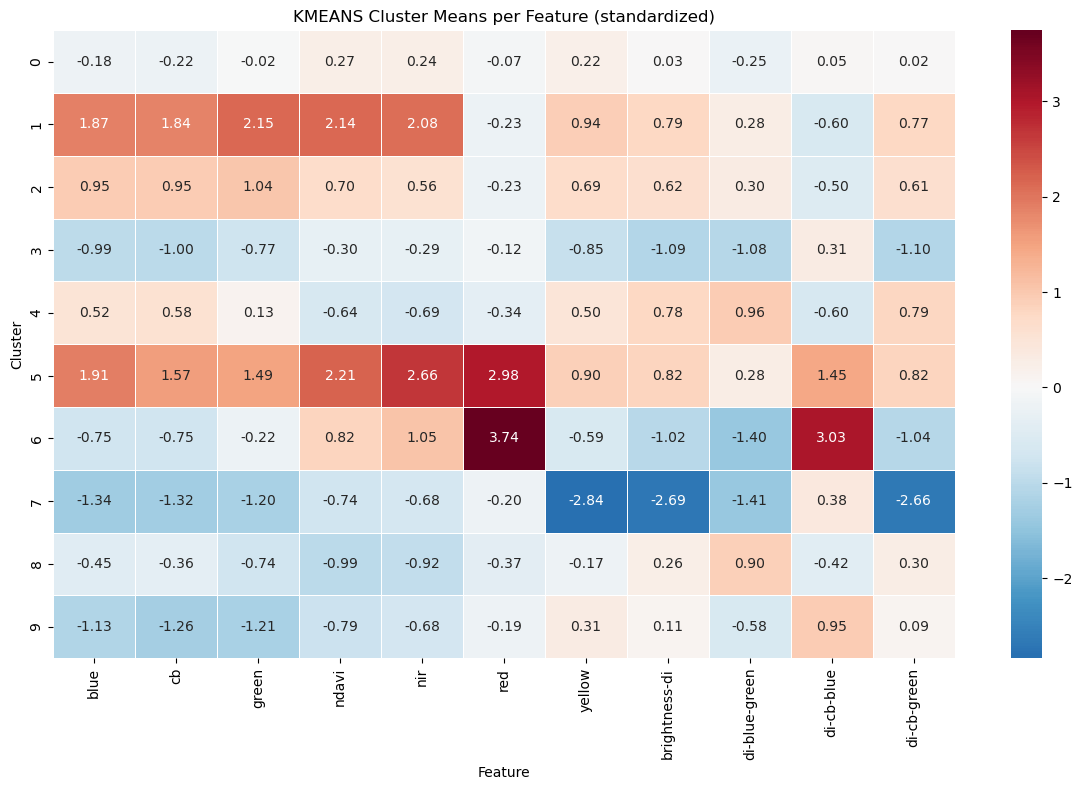

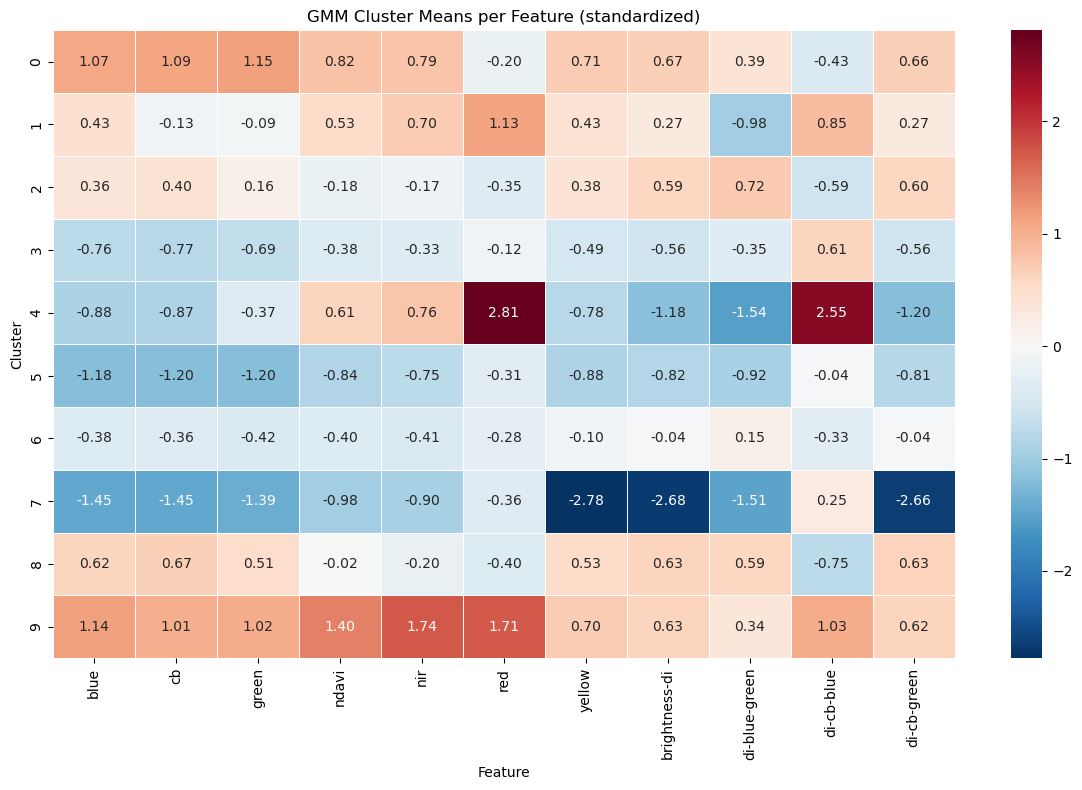

In [ ]:
feature_names = list(bands_all.keys())
means_df_kmeans = visualization.plot_cluster_means(model=kmeans, 
                                                   feature_names=feature_names,
                                                   model_type="kmeans",
                                                   file_name = f'cluster_means_{model_type}_{config.RUN_NAME}.png')
means_df_gmm = visualization.plot_cluster_means(model=gmm,
                                                feature_names=feature_names,
                                                model_type="gmm",
                                                file_name = f'cluster_means_{model_type}_{config.RUN_NAME}.png')

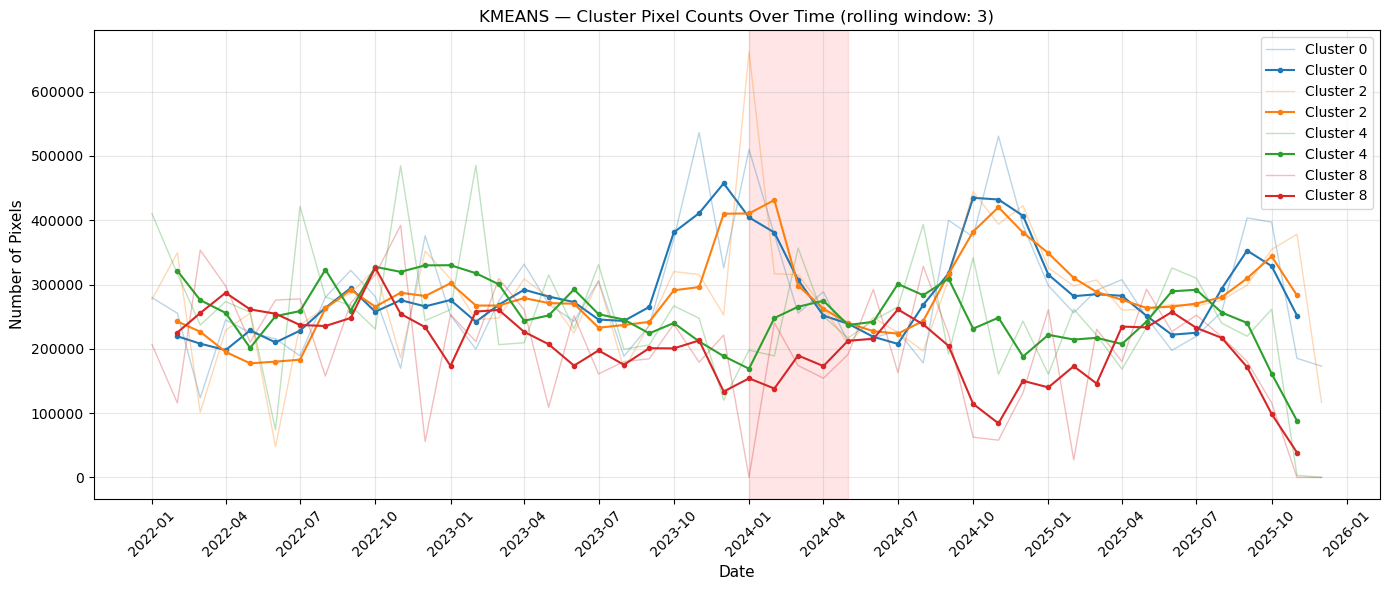

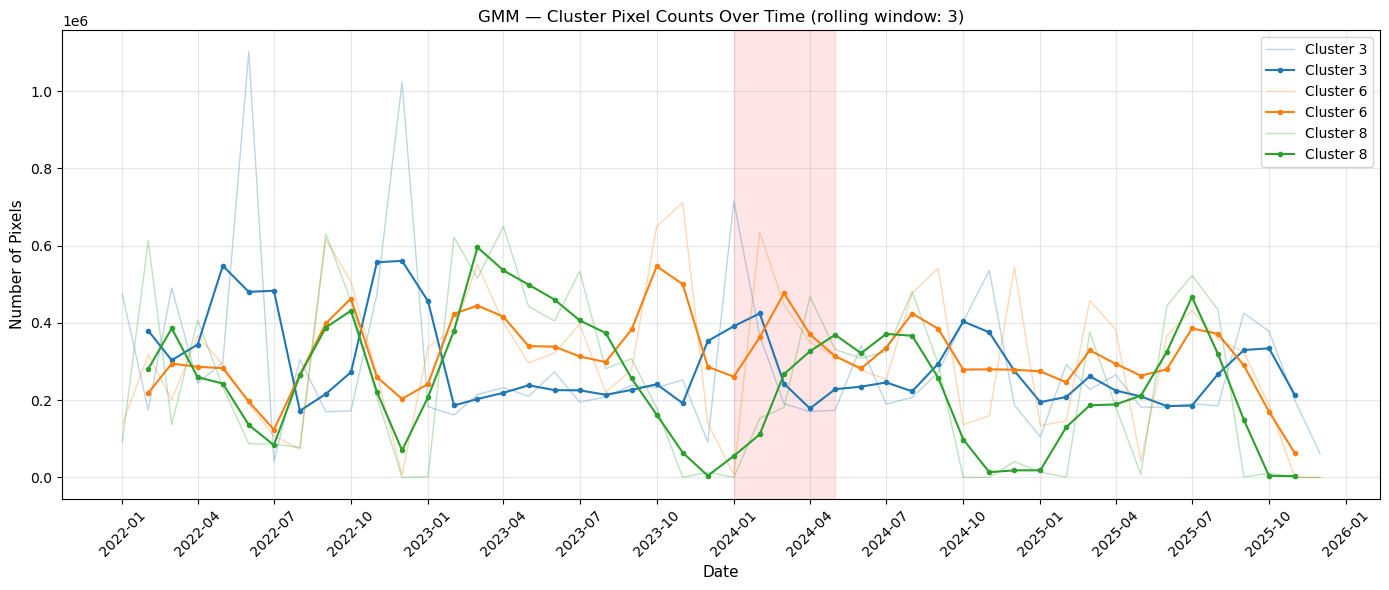

In [68]:
model_type = "kmeans"
coral_clusterIDs_kmeans = [0, 2, 4, 8]
file_name = f'total_pixels_{model_type}{"_RA" if config.ROLLING_WINDOW else ""}_timeseries_{config.RUN_NAME}.png'
visualization.plot_cluster_pixel_timeseries(
    model_type=model_type,
    cluster_ids = coral_clusterIDs_kmeans,
    labels_monthly=labels_monthly_kmeans,
    timestamps=all_timestamps,
    x_minmax=config.X_MINMAX,
    rolling_window=config.ROLLING_WINDOW,
    file_name=file_name
)

model_type = "gmm"
coral_clusterIDs_gmm = [3, 6, 8]
file_name = f'total_pixels_{model_type}{"_RA" if config.ROLLING_WINDOW else ""}_timeseries_{config.RUN_NAME}.png'
visualization.plot_cluster_pixel_timeseries(
    model_type=model_type,
    cluster_ids = coral_clusterIDs_gmm,
    labels_monthly=labels_monthly_gmm,
    timestamps=all_timestamps,
    x_minmax=config.X_MINMAX,
    rolling_window=config.ROLLING_WINDOW,
    file_name=file_name
)

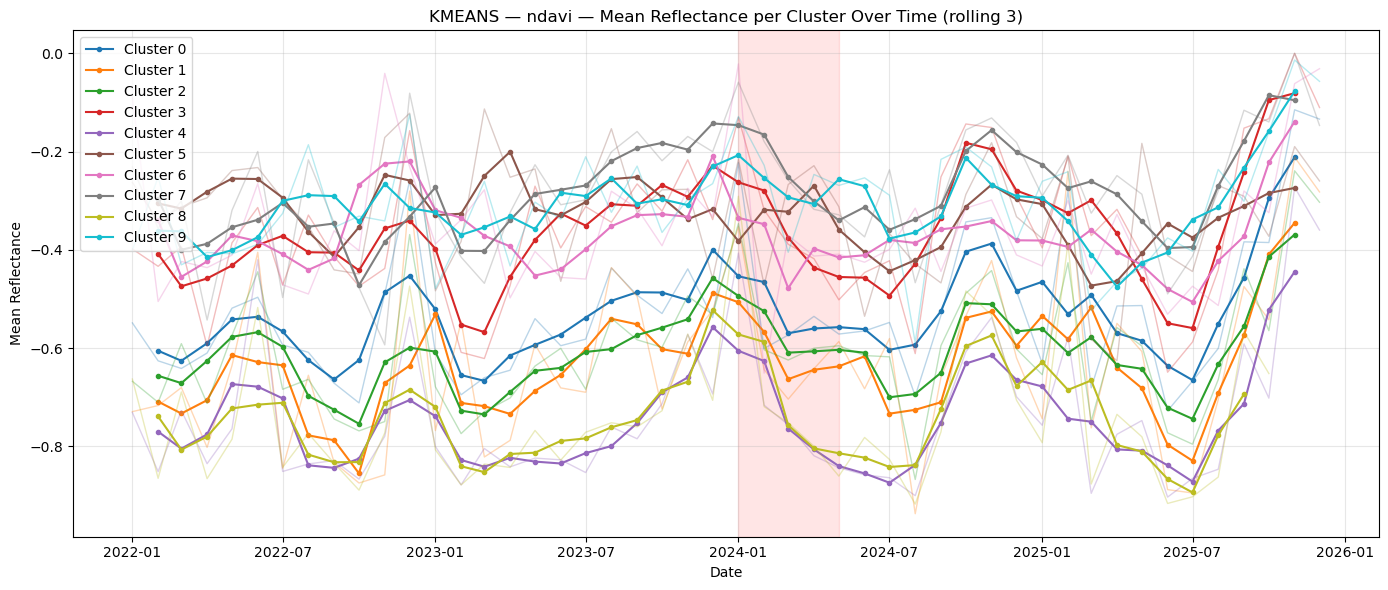

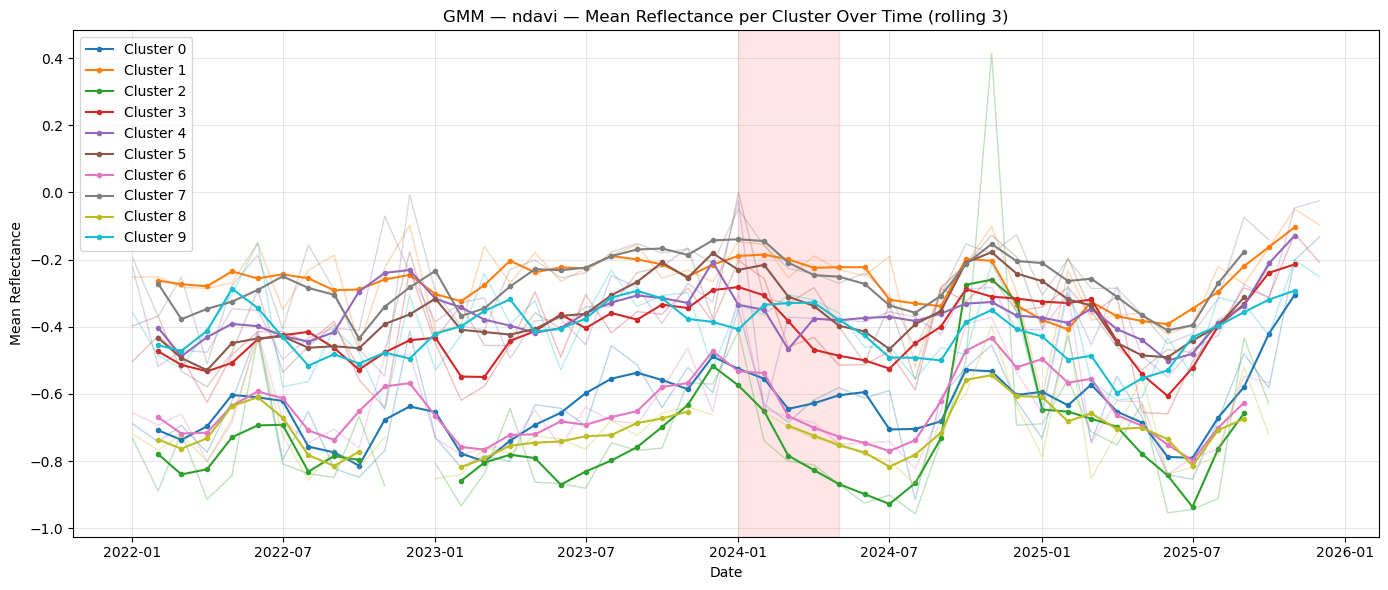

In [ ]:
band_name = "ndavi"
file_name = f'band_{band_name}_{model_type}{"_RA" if config.ROLLING_WINDOW else ""}_timeseries_{config.RUN_NAME}.png'

visualization.plot_band_cluster_timeseries(
    model_type="kmeans",
    band_name = band_name,
    cluster_ids = list(range(10)),
    labels_monthly=labels_monthly_kmeans,
    bands_all=bands_all,
    timestamps=all_timestamps,
    x_minmax=config.X_MINMAX,
    rolling_window=config.ROLLING_WINDOW,
    file_name=file_name
)

visualization.plot_band_cluster_timeseries(
    model_type="gmm",
    band_name = band_name,
    cluster_ids = list(range(10)),
    labels_monthly=labels_monthly_gmm,
    bands_all=bands_all,
    timestamps=all_timestamps,
    x_minmax=config.X_MINMAX,
    rolling_window=config.ROLLING_WINDOW,
    file_name=file_name
)

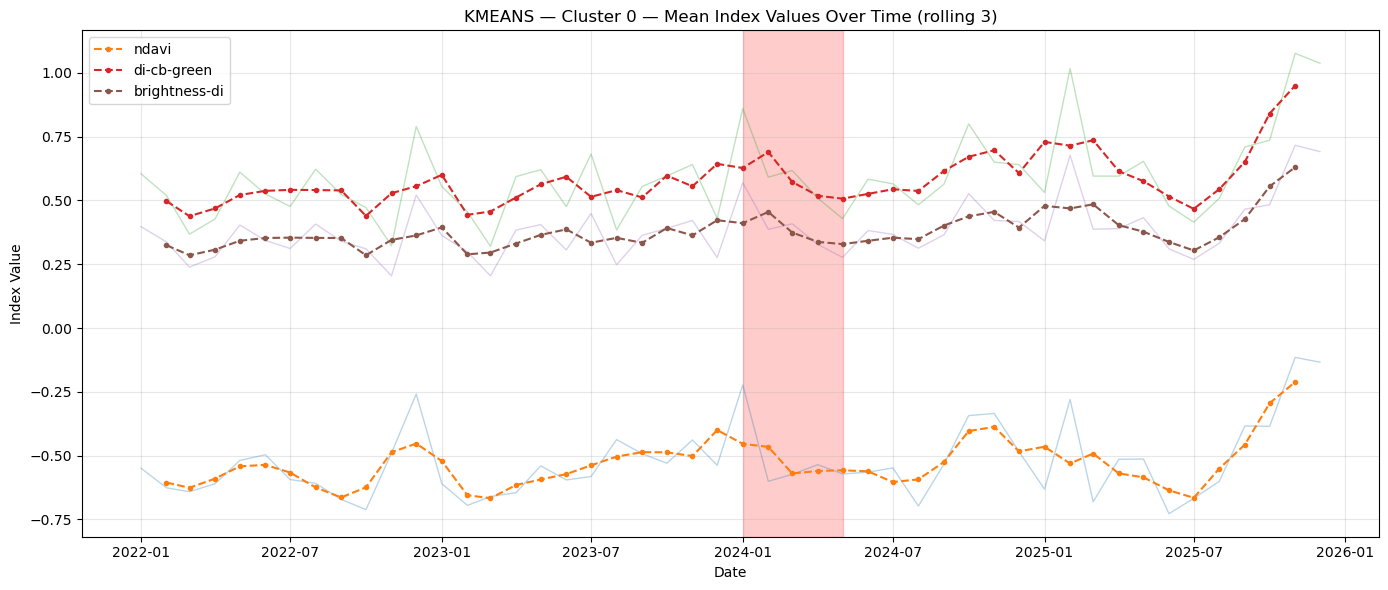

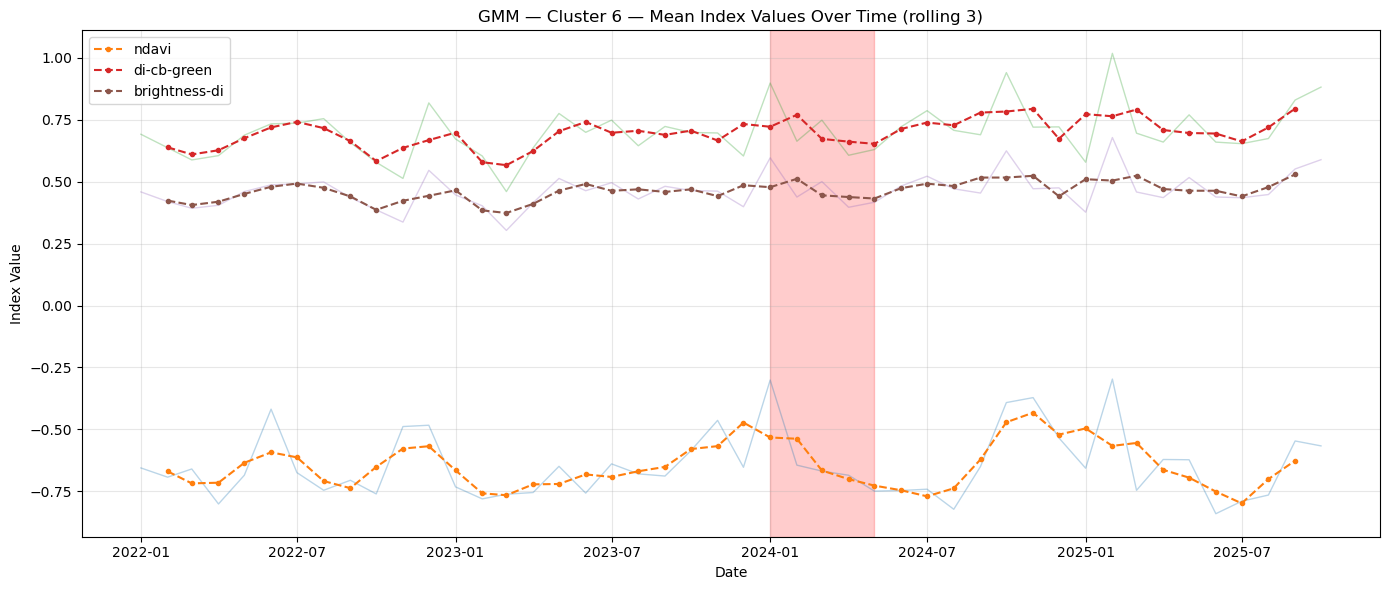

In [ ]:
cluster_id_kmeans = 0
cluster_id_gmm = 6
file_name_kmeans = f'cluster{cluster_id_kmeans}_{model_type}{"_RA" if config.ROLLING_WINDOW else ""}_timeseries_{config.RUN_NAME}.png'
file_name_gmm = f'cluster{cluster_id_kmeans}_{model_type}{"_RA" if config.ROLLING_WINDOW else ""}_timeseries_{config.RUN_NAME}.png'

visualization.plot_cluster_band_timeseries(
    model_type="kmeans",
    cluster_id=cluster_id_kmeans,
    raw_bands_to_plot=None,
    index_bands_to_plot=['ndavi', 'di-cb-green', 'brightness-di'],
    labels_monthly=labels_monthly_kmeans,
    bands_all=bands_all,
    timestamps=all_timestamps,
    x_minmax=config.X_MINMAX,
    rolling_window=config.ROLLING_WINDOW,
    file_name=file_name_kmeans
)

visualization.plot_cluster_band_timeseries(
    model_type="gmm",
    cluster_id=cluster_id_gmm,
    raw_bands_to_plot=None,
    index_bands_to_plot=['ndavi', 'di-cb-green', 'brightness-di'],
    labels_monthly=labels_monthly_gmm,
    bands_all=bands_all,
    timestamps=all_timestamps,
    x_minmax=config.X_MINMAX,
    rolling_window=config.ROLLING_WINDOW,
    file_name=file_name_gmm
)